Epoch 1/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2493.8931 
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2483.9912
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2473.8376
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2463.1396
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2450.6360
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2433.7273
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2411.2041 
Epoch 8/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2386.4229 
Epoch 9/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2352.2700 
Epoch 10/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2312.2043
Epoch 11/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2261.2034
Epoch 12/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2198.3643
Epoch 13/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2123.7668
Epoch 14/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2041.0601 
Epoch 15/2000
2/2 ━━━━━━━━━━

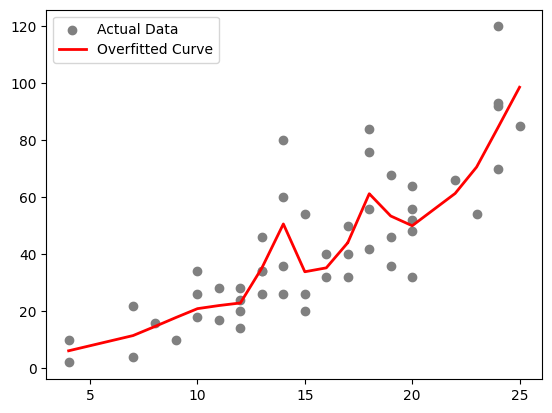

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# 1. 데이터 로드
df = pd.read_csv('../data/cars.csv') # 경로 확인 필요
X = df[['speed']].values
y = df[['dist']].values

# 2. 필수: 데이터 스케일링 (이게 없으면 활성화 함수가 제대로 작동 안 함)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

model = Sequential([
    Input(shape=(1,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# 학습률을 조금 낮춰서 더 세밀하게(과적합되게) 학습
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

# 4. 모델 학습 (에포크를 늘려 완전히 과적합 시킴)
model.fit(X_scaled, y, epochs=2000)

y_pred = model.predict(X_scaled)

plt.scatter(X, y, color='gray', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Overfitted Curve')
plt.legend()
plt.show()
